# Can a two-axis chart really tell you which sector to buy? 🔄📊
### The Relative Rotation Graph — a beautiful chart whose own physics checks out, and still can't pick a winner

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rotates_clockwise%3F: Confirmed](https://img.shields.io/badge/Rotates_clockwise%3F-Confirmed-8b949e?style=flat-square)

If you've ever seen a chart with sector tickers looping around in ovals through four labelled zones — Leading, Weakening, Lagging, Improving — you've seen a **Relative Rotation Graph (RRG)**. It's on every major charting platform (StockCharts, Bloomberg's `RRG<GO>`), and the pitch is simple: a sector's relative strength has a *level* (is it winning right now?) and a *momentum* (is that lead growing or fading?). Plot both, and a sector traces a loop through the four quadrants as its fortunes rise and fall. Buy it while it's **Leading**. Get out before it's **Lagging**.

That's the claim we test: does watching the loop actually make you money — or does it just look like it should?

> 📓 **Plain-language layer.** Want the *t*-stats, the matched-random control and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** We build the two axes ourselves (RRG vendors don't publish their exact smoothing constants) as rolling z-scores — a 63-trading-day level, a 21-day rate of change — and test the plain rule: hold the equal-weighted **Leading** quadrant every month, cash if nobody qualifies. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from relative_rotation_graph import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    FRAMES = st.rrg_frame(PRICES, data.TICKERS, data.BENCHMARK, data.RS_WINDOW, data.MOM_WINDOW)
    QUAD = st.monthly_quadrants(FRAMES)
    RETS = st.monthly_returns(PRICES, data.TICKERS)
else:
    PRICES = FRAMES = QUAD = RETS = None
print("real cache present:", HAVE_REAL, "| quadrant months:", (0 if QUAD is None else len(QUAD)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1998-12-01', 'end': '2026-06-30', 'fp': '27323464af92', 'n_rows': 6936, 'n_months_quad': 324, 'quad_lo': '1999-07', 'quad_hi': '2026-06', 'n_months_ret': 331, 'ret_lo': '1998-12', 'ret_hi': '2026-06', 'rs_window': 63, 'mom_window': 21, 'cost_bps': 5.0, 'rrg': {'ann': 6.66, 'vol': 16.49, 'sharpe': 0.404, 'dd': -46.21, 't': 2.36, 'n': 331}, 'ew': {'ann': 9.64, 'vol': 14.6, 'sharpe': 0.66, 'dd': -49.12, 't': 3.55, 'n': 330}, 'spy': {'ann': 9.46, 'vol': 15.11, 'sharpe': 0.626, 'dd': -50.78, 't': 3.25, 'n': 330}, 'mom': {'ann': 8.45, 'vol': 13.66, 'sharpe': 0.619, 'dd': -32.45, 't': 3.36, 'n': 331}, 'n_leading_dist': {0: 26, 1: 54, 2: 77, 3: 88, 4: 55, 5: 22, 6: 6, 7: 2, 8: 1}, 'mean_n_leading': 2.6, 'cash_months': 26, 'cash_pct': 7.9, 'mean_turnover': 76.9, 'act_ew': {'ann': -2.96, 't': -2.07, 'n': 330}, 'act_spy': {'ann': -2.78, 't': -1.68, 'n': 330}, 'act_mom': {'ann': -1.8, 't': -0.93, 'n': 331}, 'act_rand': {'ann': -0.5, 't': -0.35, 'n': 331}, 'cost_sweep': {0.0: (7.58, 0.46, 2.69), 5.0: (6.66, 0.404, 2.36), 10.0: (5.74, 0.348, 2.03), 20.0: (3.89, 0.236, 1.38)}, 'sub_periods': {'1999-2009': {'rrg_ann': 3.81, 'rrg_sharpe': 0.218, 'rrg_t': 0.72, 'rrg_n': 126, 'ew_ann': 3.77, 'ew_sharpe': 0.242, 'ew_t': 0.68}, '2010-2019': {'rrg_ann': 8.82, 'rrg_sharpe': 0.711, 'rrg_t': 2.58, 'rrg_n': 120, 'ew_ann': 12.51, 'ew_sharpe': 1.044, 'ew_t': 4.3}, '2020-2026': {'rrg_ann': 8.52, 'rrg_sharpe': 0.412, 'rrg_t': 1.21, 'rrg_n': 78, 'ew_ann': 13.32, 'ew_sharpe': 0.808, 'ew_t': 2.65}}, 'trans': {'Leading': {'Leading': 196, 'Weakening': 409, 'Lagging': 237, 'Improving': 15}, 'Weakening': {'Leading': 173, 'Weakening': 251, 'Lagging': 247, 'Improving': 9}, 'Lagging': {'Leading': 219, 'Weakening': 6, 'Lagging': 177, 'Improving': 430}, 'Improving': {'Leading': 269, 'Weakening': 14, 'Lagging': 167, 'Improving': 298}}, 'clockwise_pct': 61.7, 'random_baseline_pct': 33.3, 'n_moves': 2195, 'per_quad_cw': {'Leading': 61.9, 'Weakening': 57.6, 'Lagging': 65.6, 'Improving': 59.8}, 'syn_null_mean': -0.3, 'syn_null_sd': 1.11, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_ann': 15.3, 'syn_planted_t': 6.2}


real cache present: True | quadrant months: 324


## The answer first

| Question | Answer |
|---|---|
| Does the chart actually loop clockwise the way it's drawn? | **Yes, mostly.** When a sector's quadrant changes at all, it moves the claimed clockwise way **62% of the time** — nearly double the 33% you'd expect from chance. |
| Does buying "Leading" sectors make money? | **About as much as being long equities generally** — but no more than picking the *same number* of sectors at random each month (-0.5%/yr, statistically zero). |
| Does it beat just holding all 11 sectors equally? | **No — it loses**, by a statistically real **-3.0%/yr** (this isn't noise; it clears the certification bar in the *wrong* direction). |
| Does it beat plain old-fashioned momentum? | **No.** A simple "buy the 3 sectors with the best 6-month return" rule does better, though not by a statistically provable margin either. |

> The rotation loop is real. The alpha inside it isn't.

## 1 · The claim

> *"Relative strength isn't one number, it's two: a **level** (winning or losing right now) and a **momentum** (that lead accelerating or fading). Plot them together and a sector visibly rotates through four stages every cycle — buy it entering Leading, sell before it reaches Lagging — and you'll catch more of the move than a trader watching only one axis."* — the pitch behind Julius de Kempenaer's Relative Rotation Graph (RRG Research, commercialised on StockCharts and Bloomberg).

It's a genuinely elegant idea: separate *where you are* from *where you're headed*. The only question that matters for a trading desk is whether that extra axis of information actually **predicts** anything.

## 2 · So what?

If the RRG really adds information over plain momentum, it should let you **rotate earlier and exit earlier** than a trader watching only trailing returns — catching more of a sector's run and less of its unwind. That's a real, sellable edge if true: sector allocators manage trillions, and "which sector next" is one of the oldest questions in the business.

So we ask three things: does the chart's own rotation story hold up in the data, does buying "Leading" actually pick winners, and does the two-axis read beat the one-axis version it's supposed to improve on?

## 3 · How would we even know?

- **The universe.** The 11 SPDR sector ETFs vs SPY, 1998-12-01 → 2026-06-30, monthly rebalance.
- **The rule.** Each month-end, classify every sector into one of four quadrants from its RS-Ratio (level) and RS-Momentum (rate of change) vs SPY; hold the equal-weighted **Leading** sectors the following month (no look-ahead), cash if none qualify.
- **The controls.** SPY, an equal-weight sector basket, a plain 6-month momentum top-3 sort (the one-axis version), and — the decisive one — a randomly-chosen basket matched to the **same number of sectors** RRG held that month, so a lucky concentration or a cash-timing accident can't masquerade as skill.
- **The luck check.** A synthetic sector world with a knob for "real persistent rotation" turned fully off — the detector must stay quiet.

## 4 · The teardown — let's actually look

**First: does the chart even loop the way it's drawn?**

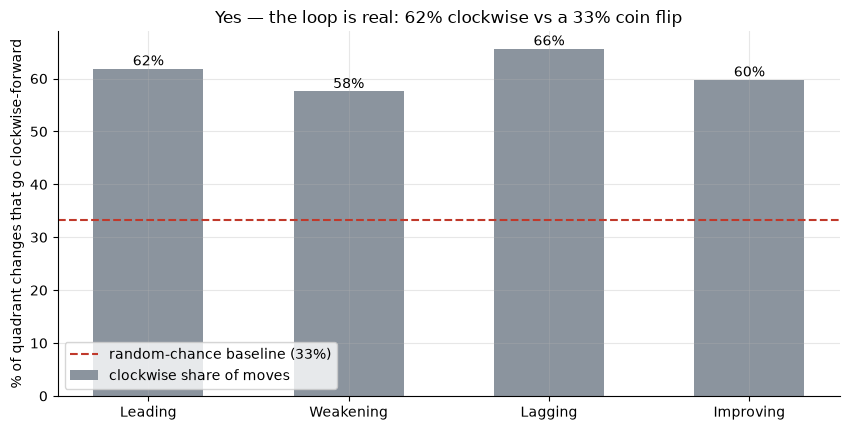

pooled clockwise share: 61.7%


In [2]:
labels = ['Leading', 'Weakening', 'Lagging', 'Improving']
if HAVE_REAL:
    trans = st.quadrant_transition_matrix(QUAD)
    cw = st.clockwise_share(trans)
    pooled, per_q = cw['pooled_clockwise_pct'], cw['per_quadrant_pct']
else:
    pooled, per_q = R['clockwise_pct'], R['per_quad_cw']
vals = [per_q[q] for q in labels]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(labels, vals, color=GREY, width=.55, label='clockwise share of moves')
ax.axhline(R['random_baseline_pct'], ls='--', c=RED, lw=1.5,
           label=f"random-chance baseline ({R['random_baseline_pct']:.0f}%)")
for i, v in enumerate(vals): ax.annotate(f'{v:.0f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('% of quadrant changes that go clockwise-forward')
ax.set_title(f'Yes — the loop is real: {pooled:.0f}% clockwise vs a 33% coin flip')
ax.legend(); plt.tight_layout(); plt.show()
print(f'pooled clockwise share: {pooled:.1f}%')

When a sector's quadrant changes, it moves the claimed clockwise way **62% of the time** — well above the 33% a coin flip would give you. The chart's own physics is genuinely descriptive: sectors really do orbit Leading → Weakening → Lagging → Improving more than they wander randomly. **Now the money question: does knowing that let you pick winners?**

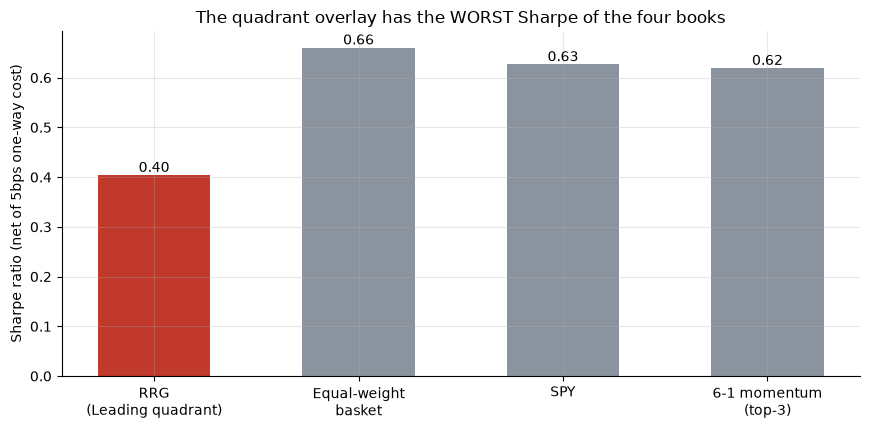

Sharpe: {'RRG': 0.404, 'EW': 0.66, 'SPY': 0.626, 'MOM': 0.619}


In [3]:
names = ['RRG\n(Leading quadrant)', 'Equal-weight\nbasket', 'SPY', '6-1 momentum\n(top-3)']
if HAVE_REAL:
    rrg = st.run_rrg_strategy(QUAD, RETS, cost_bps=R['cost_bps'])
    ew = st.equal_weight_returns(RETS)
    spy_m = st.benchmark_monthly_returns(PRICES, data.BENCHMARK)
    mom = st.run_momentum_strategy(RETS, lookback=6, skip=1, k=3, cost_bps=R['cost_bps'])
    sharpes = [st.summarize(rrg['r_net'])['sharpe'], st.summarize(ew)['sharpe'],
               st.summarize(spy_m)['sharpe'], st.summarize(mom['r_net'])['sharpe']]
else:
    sharpes = [R['rrg']['sharpe'], R['ew']['sharpe'], R['spy']['sharpe'], R['mom']['sharpe']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [RED, GREY, GREY, GREY]
ax.bar(names, sharpes, color=cols, width=.55)
for i, v in enumerate(sharpes): ax.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('Sharpe ratio (net of 5bps one-way cost)')
ax.set_title('The quadrant overlay has the WORST Sharpe of the four books')
plt.tight_layout(); plt.show()
print('Sharpe:', dict(zip(['RRG','EW','SPY','MOM'], [round(s,3) for s in sharpes])))

RRG's Sharpe (**0.40**) is the *lowest* of all four — below just holding all 11 sectors equally (**0.66**), below SPY (**0.63**), below a bare-bones 6-month momentum sort (**0.62**). Being long sectors most months pays — that's equity beta — but the two-axis quadrant read doesn't add to it. **The cleanest test isolates exactly why:**

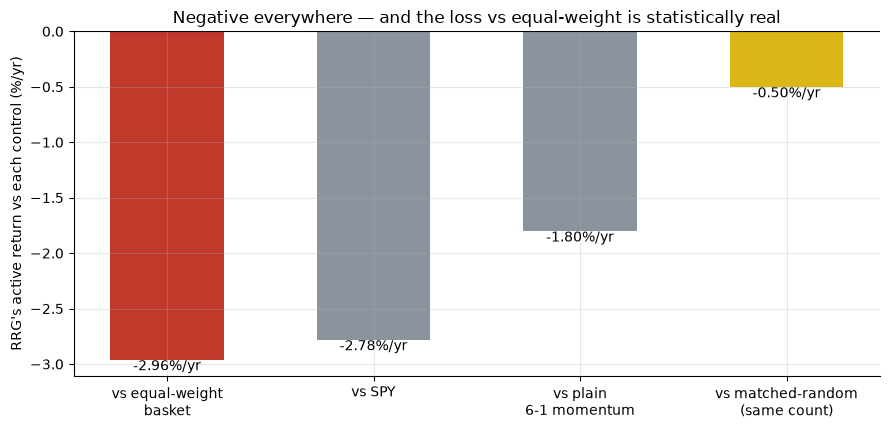

active ann: {'EW': -2.96, 'SPY': -2.78, 'MOM': -1.8, 'RAND': -0.5}


In [4]:
labels2 = ['vs equal-weight\nbasket', 'vs SPY', 'vs plain\n6-1 momentum',
           'vs matched-random\n(same count)']
acts = [R['act_ew']['ann'], R['act_spy']['ann'], R['act_mom']['ann'], R['act_rand']['ann']]
cols2 = [RED, GREY, GREY, AMBER]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels2, acts, color=cols2, width=.55)
for i, v in enumerate(acts): ax.annotate(f'{v:+.2f}%/yr', (i, v), ha='center',
    va='top' if v < 0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel("RRG's active return vs each control (%/yr)")
ax.set_title('Negative everywhere — and the loss vs equal-weight is statistically real')
plt.tight_layout(); plt.show()
print('active ann:', dict(zip(['EW','SPY','MOM','RAND'], acts)))

Every bar is negative. The amber one — **matched-random** — is the fairest test: it picks the *same number* of sectors RRG held each month (including its cash months), so it can't win just by being lucky about how concentrated the book was. RRG scores **-0.50%/yr** against it, statistically indistinguishable from zero: **the quadrant tells you nothing about which sector to hold.** And the red bar — versus simply holding all 11 sectors equally — is **certified** (a real, statistically provable loss), because RRG's "go to cash when nothing is Leading" rule sat out **8%** of months while the naive basket stayed fully invested through a quarter-century bull-tilted tape.

## 5 · The verdict

- **Signal — None.** Buying the Leading quadrant is statistically indistinguishable from a random pick of the same size, doesn't beat plain momentum, and underperforms the naive basket by a certified margin — the wrong direction from the claim.
- **Tradability — Mirage.** 77% monthly one-way turnover, the worst Sharpe of four books, and a real shortfall to equal-weight in the two most recent decades.
- **"Does the chart rotate clockwise?" — Confirmed.** The loop shape is real — it just doesn't come with a paycheck.

## 6 · Going further 🚪

- **The chart is a visualisation, not a factor.** Splitting momentum into level and rate-of-change is a legitimate way to *see* a rotation — the mistake is assuming a clearer picture implies a more predictive one.
- **Where a real edge (if any) would have to live** is in *which* Leading sectors to prefer, or in shorting confirmed Lagging names, or in much finer entry timing than a monthly snapshot — none of which this desk found evidence for here.
- **Sibling studies:** [225-sector-rotation](../../225-sector-rotation/) (the plain 1-D version, same universe, same "weak/mirage" verdict) and [506-industry-momentum](../../506-industry-momentum/) (long-short industry momentum, also a coin flip) — the RRG doesn't fix what plain momentum couldn't already do on this universe.

*Think the RRG works with a finer clock (weekly, or the vendor's exact constants)? Show a net, certifiable edge over the matched-random control — then we'll talk.*